In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.decomposition import PCA 

sns.set_style("whitegrid")

# **Task 1: Data Exploration**

Load the Titanic dataset from seaborn and get familiar with its structure.

    titanic = sns.load_dataset("titanic")

1. Display the first few rows and inspect the shape of the dataset.
2. Check data types for each column. Which are numerical? Which are categorical?
3. Identify missing values — which columns have them, and what percentage of values are missing?
4. Examine the class balance of the target variable (survived). What is the survival rate?
5. Create at least two visualizations: one showing the distribution of a numerical feature (e.g., age) and one showing survival rates broken down by a categorical feature (e.g., pclass or sex).

Write a brief summary of your findings in a markdown cell.

In [2]:
titanic = sns.load_dataset("titanic")
df = titanic

In [3]:
df.shape

(891, 15)

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Titanic Dataset Column Descriptions

| Column Name | Description | Key / Values |
| :--- | :--- | :--- |
| **survived** | Survival status | 0 = No, 1 = Yes |
| **pclass** | Passenger Class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **sex** | Gender | male, female |
| **age** | Age | Age in years |
| **sibsp** | Siblings / Spouses | Number of siblings or spouses aboard |
| **parch** | Parents / Children | Number of parents or children aboard |
| **fare** | Passenger fare | The amount of money spent on the ticket |
| **embarked** | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |
| **class** | Ticket class | First, Second, Third |
| **who** | Category | man, woman, child |
| **adult_male** | Adult male status | True, False |
| **deck** | Cabin deck | The level/floor where the cabin was located (A-G) |
| **embark_town** | City of embarkation | Southampton, Cherbourg, Queenstown |
| **alive** | Survival status | yes, no |
| **alone** | Traveling alone | True (if no family aboard), False (if with family) |


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [8]:
# Numerical columns (int and float)
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Categorical columns (object, category, bool)
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

# ------
# Why did we write just number for numerical columns but 'object', 'category', 'bool'for categorical?
# ------
# When we write include=['number'] - Pandas accepts all the number types(including int 64,float32,float64 and etc.) 
# Because we have smth to say their name as general.

# But when it comes to categorical values there is no general name which can be named for all of the words.
# So,that is why we should write them one by one.

Numeric columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [9]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
round((df.isna().sum() / len(df))*100,2)

survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64

In [11]:
# Examine the class balance of the target variable (survived). What is the survival rate?

In [12]:
sum(df['survived']==1)

342

In [13]:
round(sum(df['survived']==1) / len(df),2)

0.38

In [14]:
ps_1 = sum((df['survived']==1) & (df['pclass']==1))
ps_1

136

In [15]:
ps_1_rate = round(ps_1 / sum(df['pclass']==1),2)
ps_1_rate

0.63

In [16]:
ps_2 = sum((df['survived']==1) & (df['pclass']==2))
ps_2

87

In [17]:
ps_2_rate = round(ps_2 / sum(df['pclass']==2),2)
ps_2_rate

0.47

In [18]:
ps_3 = sum((df['survived']==1) & (df['pclass']==3))
ps_3

119

In [19]:
ps_3_rate = round(ps_3 / sum(df['pclass']==3),2)
ps_3_rate

0.24

In [20]:
# Another way
df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [21]:
# Create at least two visualizations: one showing the distribution of a numerical feature (e.g., age) and one showing survival rates broken down 
# by a categorical feature (e.g., pclass or sex).

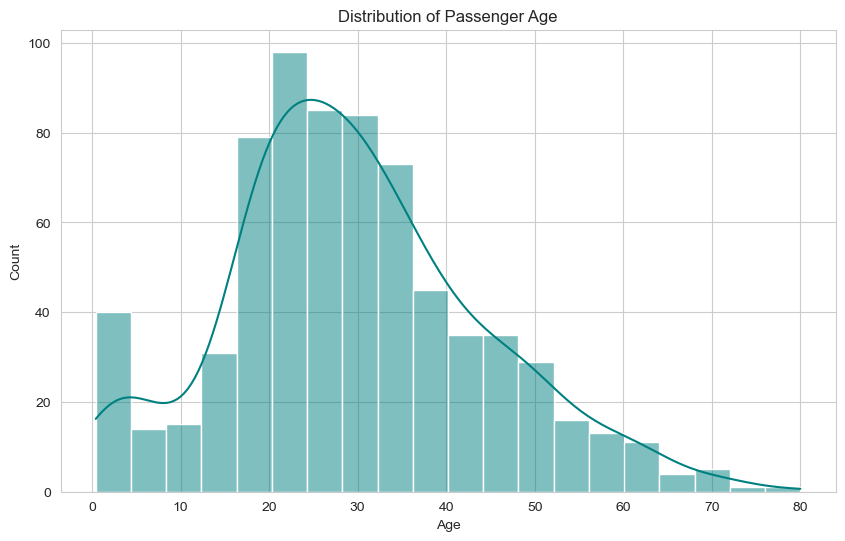

In [22]:
# 1. Numerical Feature Distribution (Age)
# --------
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(10,6))
sns.histplot(df['age'].dropna(),kde=True,color='teal')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

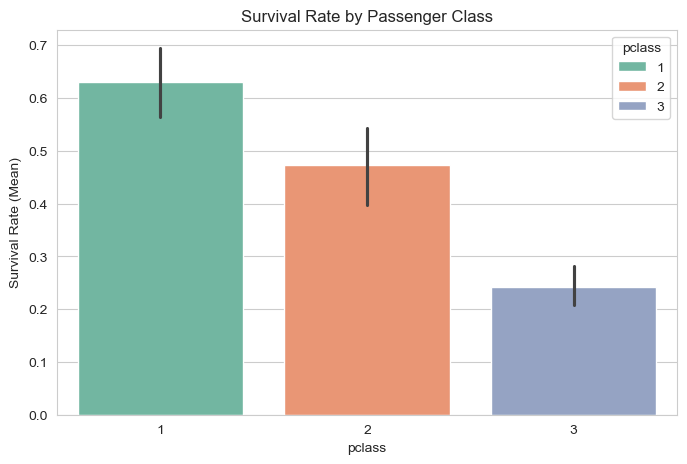

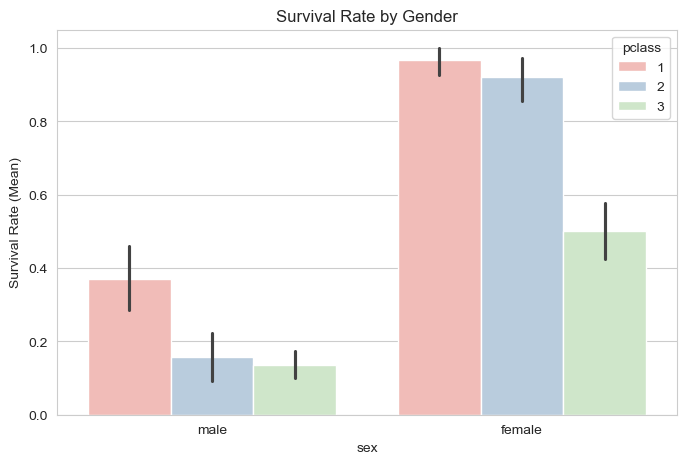

In [23]:
# 2. Survival Rate by Categorical Features (Class and Sex)
# --------

plt.figure(figsize=(8, 5))
sns.barplot(x='pclass', y='survived', data=df, palette='Set2',hue='pclass', legend=True)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate (Mean)')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='sex', y='survived', data=df, palette='Pastel1',hue='pclass', legend=True)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate (Mean)')
plt.show()

### What are the "Black Lines" on a Bar Plot?

The black lines at the top of the bars are called **Error Bars**. In the context of Seaborn’s `barplot`, they represent the **95% Confidence Interval (CI)**.

* **The Bar Height:** Represents the **mean** (average) value for that category (e.g., the average survival rate).
* **The Error Bar (The Black Line):** Indicates the **uncertainty** or the range within which the true population mean is likely to fall.



### How to interpret them:

1.  **Short Lines (Precision):** A short error bar suggests that the data points are consistent and the sample size is large enough. We are very confident that the calculated average is close to the true value.
2.  **Long Lines (Variability):** A long error bar indicates high variability in the data or a small sample size. This means the average might be less "stable" or less certain.
3.  **Overlapping Bars:** If the error bars of two categories overlap significantly, it suggests that the difference between their averages might not be **statistically significant**.

> **Note:** By default, Seaborn uses bootstrapping to calculate this 95% confidence interval. It essentially tells the viewer: *"We are 95% sure that the actual survival rate for this group falls within this black line."*



--------------------
# **Task 2: Feature Engineering*

Transform the raw features into a format suitable for machine learning.

**1. Handle missing values:**

- Fill missing age values with the median age.
- Fill missing embarked values with the mode (most frequent value).
- Drop the deck column (too many missing values to be useful).


In [24]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [25]:
df['age'] = df['age'].fillna(df['age'].median())

In [26]:
df['age'].isna().sum()

np.int64(0)

In [27]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [28]:
df['embarked'].isna().sum()

np.int64(0)

In [29]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [30]:
df = df.drop(columns = ['deck'],axis=1)

In [31]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')


2. **Encode categorical features:**

- Apply label encoding to sex (male → 1, female → 0).
- Apply one-hot encoding to embarked (creating dummy columns).


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

df['sex']

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: sex, Length: 891, dtype: int64

In [33]:
df['embarked'].isna().sum()

np.int64(0)

In [34]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Initialize and transform in fewer steps
ohe = OneHotEncoder(sparse_output=False, drop='first')
embarked_data = ohe.fit_transform(df[['embarked']])

# Create DataFrame with descriptive column names
embarked_df = pd.DataFrame(embarked_data, 
                           columns=ohe.get_feature_names_out(['embarked']), 
                           index=df.index)

# Merge and drop the original column
df = pd.concat([df.drop(columns=['embarked']), embarked_df], axis=1)

**To handle the categorical feature embarked, I used the OneHotEncoder from Scikit-Learn. This technique transforms categorical labels into a series of binary columns (0s and 1s), allowing the machine learning model to process the data without assuming any numerical order between the ports. I applied drop='first' to avoid the *dummy variable trap (multicollinearity),* (i.e if Q=0 and S=0 it means C=1.There is no need to add another column - C) which removes one redundant column while retaining all necessary information.**


**3. Create new features:**

- family_size = sibsp + parch + 1 (the passenger plus their siblings/spouses and parents/children).
- is_alone = 1 if family_size == 1, else 0.



In [35]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = df['family_size'].apply(lambda x:1 if x == 1 else 0)

In [36]:
df.groupby('is_alone')['survived'].mean()

is_alone
0    0.505650
1    0.303538
Name: survived, dtype: float64

**4. Drop non-numeric and identifier columns that won't be useful for modeling (e.g., alive, who, adult_male, embark_town, class, alone).**

In [37]:
df = df.drop ( columns = ['alive', 'who', 'adult_male', 'embark_town', 'class', 'alone'],axis=1)

In [38]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked_Q', 'embarked_S', 'family_size', 'is_alone'],
      dtype='object')

**5. Display the final DataFrame and confirm all columns are numeric.**

In [39]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,0.0,1.0,2,0
1,1,1,0,38.0,1,0,71.2833,0.0,0.0,2,0
2,1,3,0,26.0,0,0,7.9250,0.0,1.0,1,1
3,1,1,0,35.0,1,0,53.1000,0.0,1.0,2,0
4,0,3,1,35.0,0,0,8.0500,0.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,0.0,1.0,1,1
887,1,1,0,19.0,0,0,30.0000,0.0,1.0,1,1
888,0,3,0,28.0,1,2,23.4500,0.0,1.0,4,0
889,1,1,1,26.0,0,0,30.0000,0.0,0.0,1,1


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked_Q   891 non-null    float64
 8   embarked_S   891 non-null    float64
 9   family_size  891 non-null    int64  
 10  is_alone     891 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 76.7 KB


---------------------------

# **Task 3: Feature Scaling & Selection*

Apply scaling techniques and identify the most relevant features.

**1. Compare scalers:** 

- Apply both StandardScaler and MinMaxScaler to the numeric features. Plot the distributions of age and fare before and after each scaling method (use histograms or KDE plots). In a markdown cell, explain the difference between the two approaches.

### **StandardScaler vs. MinMaxScaler**

In Machine Learning, **Feature Scaling** is essential because most algorithms are sensitive to the magnitude of the data. Here is how to choose between the two most common methods:

---

#### **1. StandardScaler (Z-score Normalization)**
StandardScaler shifts the data distribution so that the **mean is 0** and the **standard deviation is 1**.

* **When to use:**
    * When the data follows a **Normal (Gaussian) Distribution**.
    * When your dataset contains **Outliers**. It is more robust because it doesn't "squash" the outliers into a small range.
    * Commonly used with algorithms like **Logistic Regression, SVM, and Neural Networks**.



---

#### **2. MinMaxScaler (Normalization)**
MinMaxScaler transforms the data by scaling it into a specific range, typically **[0, 1]**.

* **When to use:**
    * When you need your data to be within a **fixed range**.
    * When the dataset has **no outliers**, or you are certain about the minimum and maximum boundaries.
    * Essential for algorithms that rely on distances, like **K-Nearest Neighbors (KNN)**, or image processing tasks where pixel values are usually scaled between 0 and 1.

---

### **Quick Comparison Table**

| Feature | **StandardScaler** | **MinMaxScaler** |
| :--- | :--- | :--- |
| **Outliers** | More robust (Handles outliers better). | Very sensitive (One outlier can ruin the scaling). |
| **Output Range** | Not fixed (Usually between -3 and 3). | Strictly between **0 and 1**. |
| **Data Shape** | Preserves the shape of the distribution. | Compresses the data into a "box". |
| **Best For** | Algorithms assuming normal distribution. | Algorithms relying on distances (KNN, K-Means). |



---

#### **Final Recommendation for Titanic Dataset:**
> "For the Titanic dataset, **StandardScaler** is often preferred for features like `Age` and `Fare`. Since `Fare` typically has significant outliers (very expensive tickets), MinMaxScaler would compress the majority of the data into a tiny range near zero, losing valuable information. StandardScaler handles this variety much more effectively."



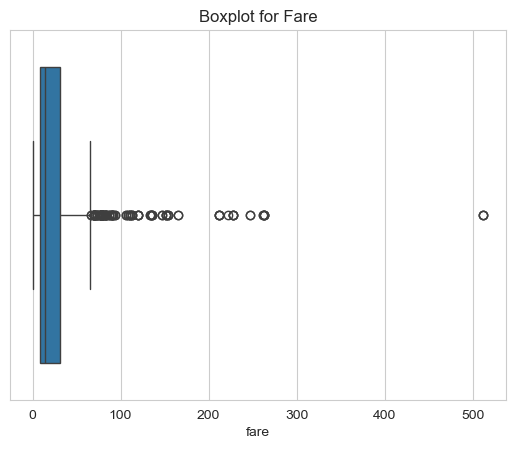

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fare (Bilet qiyməti) sütunu üçün outlier yoxlaması
sns.boxplot(x=df['fare'])
plt.title('Boxplot for Fare')
plt.show()


### **1. Analysis of Fare Boxplot**
* **Distribution:** The data is heavily **right-skewed**, meaning most passengers paid a low fare, while a few paid extremely high prices.
* **Central Tendency:** The **Median** is very close to the left side of the box, indicating that more than 50% of passengers traveled with very cheap tickets.
* **Outliers:** There are numerous outliers beyond the upper whisker (starting from approx. $70 up to $512). These represent high-income or first-class passengers.
* **Modeling Note:** Because the outliers are so extreme, **StandardScaler** is more appropriate than MinMaxScaler to prevent the data from being squashed into a tiny range.



**Interpretation of the Fare Boxplot:**

"The boxplot for the fare feature reveals a significant right-skewed distribution with a high density of values at lower price points. The presence of numerous outliers beyond the upper whisker (approximately above 70) indicates that a small group of passengers paid exceptionally high fares compared to the majority. This confirms that using a StandardScaler would be more appropriate than a MinMaxScaler, as the latter would compress the majority of the data into a very narrow range due to the extreme outlier at 500+."

In [42]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['fare'] < lower_limit) | (df['fare'] > upper_limit)]
print(f"Count of outliers: {len(outliers)}")

Count of outliers: 116


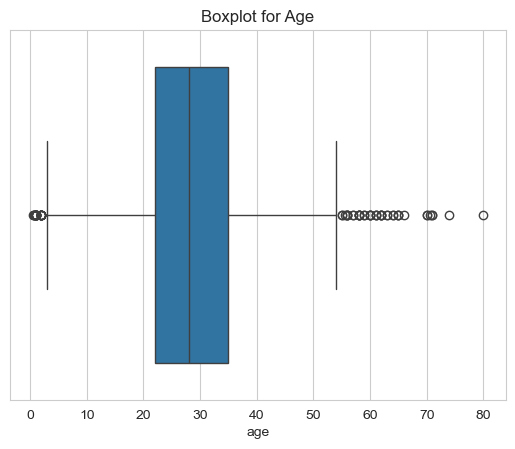

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fare (Bilet qiyməti) sütunu üçün outlier yoxlaması
sns.boxplot(x=df['age'])
plt.title('Boxplot for Age')
plt.show()



### **2. Analysis of Age Boxplot**
* **Normal Range:** Most passengers are within the **5 to 54** age range (represented by the whiskers).
* **The "Core" Group:** The blue box represents the middle 50% of the passengers. Their ages are concentrated between approximately **22 and 35** years old.
* **Median:** The median age is around **28**, showing that the Titanic was mostly populated by young adults.
* **Outliers:** * **Low end:** There are "young" outliers (infants and children aged 0-5). 
    * **High end:** There are "elderly" outliers (seniors aged 55-80). 
* **Data Density:** Since the box is neither too narrow nor too wide, it shows a moderate and healthy variation in age, unlike the extreme gaps seen in the `Fare` column.




In [44]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Scalers
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

# Copy datas
df_std = df.copy()
df_mm = df.copy()

# Implementing Scaling 
df_std[numeric_cols] = std_scaler.fit_transform(df[numeric_cols])
df_mm[numeric_cols] = mm_scaler.fit_transform(df[numeric_cols])

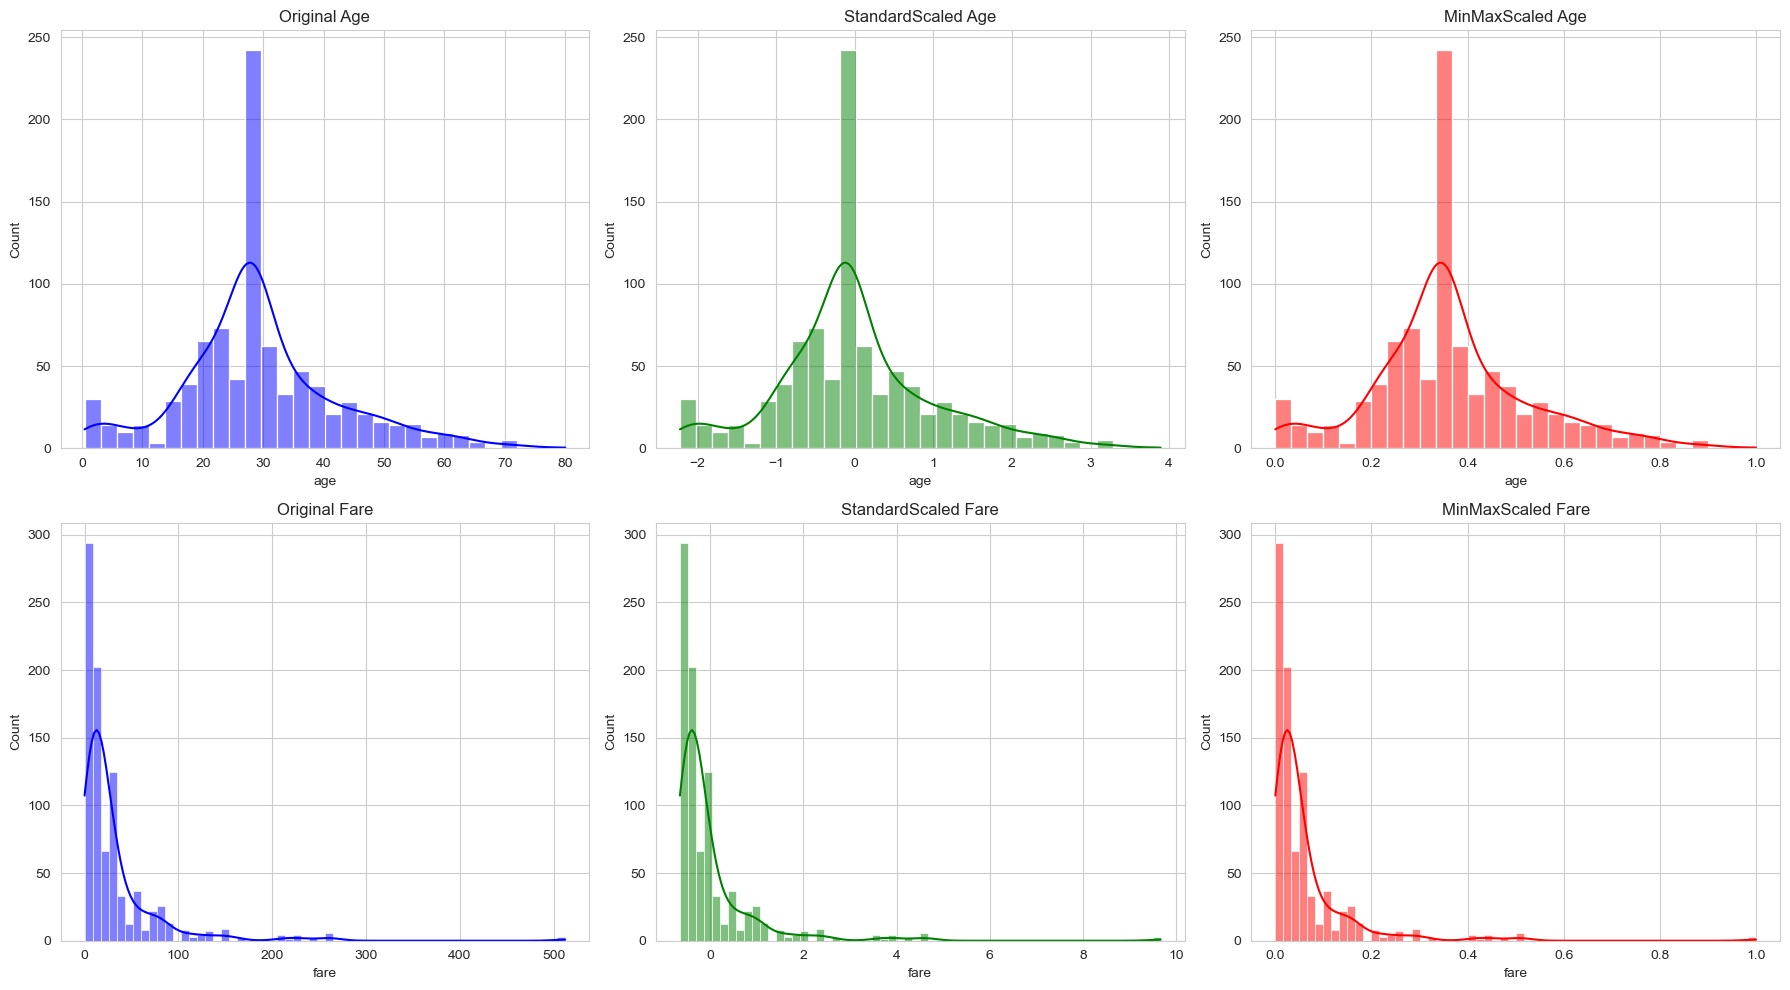

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- For AGE column ---
# Original
sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='blue').set_title('Original Age')
# StandardScaler
sns.histplot(df_std['age'], kde=True, ax=axes[0, 1], color='green').set_title('StandardScaled Age')
# MinMaxScaler
sns.histplot(df_mm['age'], kde=True, ax=axes[0, 2], color='red').set_title('MinMaxScaled Age')

# --- For FARE column ---
# Original
sns.histplot(df['fare'], kde=True, ax=axes[1, 0], color='blue').set_title('Original Fare')
# StandardScaler
sns.histplot(df_std['fare'], kde=True, ax=axes[1, 1], color='green').set_title('StandardScaled Fare')
# MinMaxScaler
sns.histplot(df_mm['fare'], kde=True, ax=axes[1, 2], color='red').set_title('MinMaxScaled Fare')

plt.tight_layout()
plt.show()


### **Interpretation**


**StandardScaler:**
* **How it works:** It centers the data by removing the mean and scaling to unit variance ($mean=0, std=1$).
* **Observation:** The shape of the distribution remains the same. The values are typically centered around 0, extending to roughly -3 and +3. It handles the extreme outliers in the `fare` column better than MinMaxScaler.



**MinMaxScaler:**
* **How it works:** It shrinks the data within a fixed range, usually **[0, 1]**.
* **Observation:** For the `age` column, it works well. However, for the `fare` column, the extreme outlier (512$) forces all other values to be squashed very close to 0. This makes it harder for the model to see the differences between smaller fare values.



**Difference:**
The main difference is that **StandardScaler** is robust to outliers and maintains the "shape" of the distribution, while **MinMaxScaler** is highly sensitive to outliers and forces everything into a strict box. For Titanic, StandardScaler is generally the safer choice because of the high variance in ticket prices.



**2.Correlation analysis: Compute the correlation matrix for all numeric features. Plot it as a heatmap with annotations. Which features have the strongest positive and negative correlations with survived?**

**Correlation Analysis : Which feature affects surviving and how?**

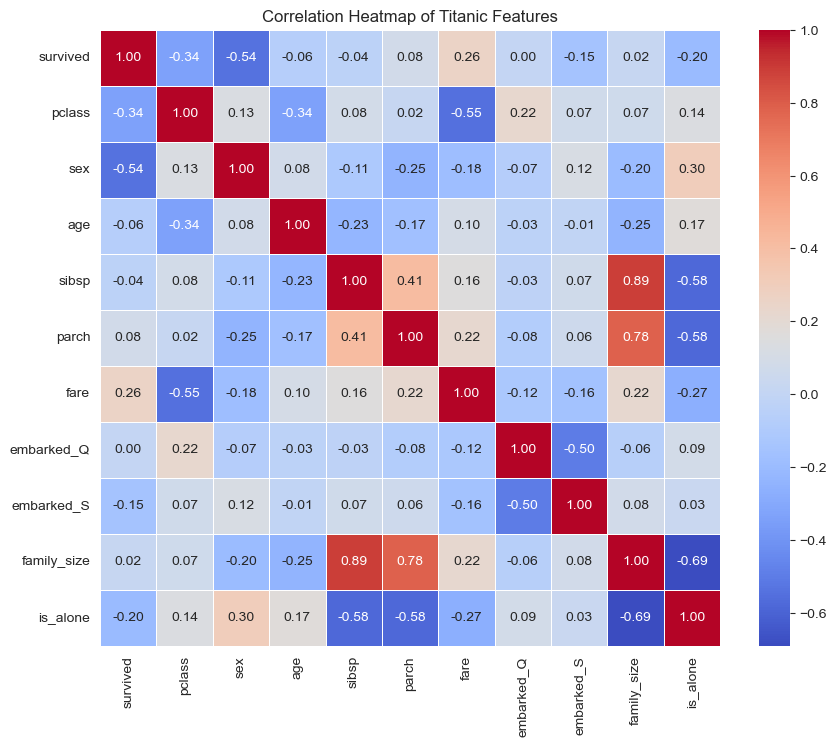

In [46]:
# Calculation
corr_matrix = df.select_dtypes(include=['number']).corr()

# Heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Features')
plt.show()

> **Findings from the Correlation Heatmap:**
> * **Highest Impact:** Gender (**`sex`**) has the strongest negative correlation (-0.54) with survival, confirming that female passengers had a significantly higher survival rate.
> * **Socio-Economic Status:** **`pclass`** (-0.34) and **`fare`** (0.26) show that passengers in higher classes and those who paid more had better survival prospects.
> * **Family Dynamics:** Being alone (**`is_alone`**: -0.20) was a disadvantage. Additionally, there is a very high correlation (**0.89**) between `family_size` and `sibsp`. It means there is correlation between them and for not making confused our model it would be better to delete one of them.
> ----
> * **Positive Correlation:** The feature fare shows the strongest positive correlation with survival. This suggests that passengers who paid higher fares (mostly first-class) had a higher probability of surviving.

> * **Negative Correlation:** The feature pclass shows the strongest negative correlation with survival. This indicates that as the class number increases (from 1st to 3rd class), the survival rate decreases significantly.

> * **Observation:** This confirms that socio-economic status played a crucial role in the survival of Titanic passengers.

**3. Feature selection: Based on the correlation matrix, select the top features most correlated with the target (absolute correlation ≥ 0.1). List them and briefly justify keeping or dropping borderline features.**

> **Feature Selection Based on Correlation ($|r| \ge 0.1$):**
>
> 1. **sex (0.54):** Highest correlation; indispensable for the model.
> 2. **pclass (0.34):** Strong indicator of socio-economic status and survival priority.
> 3. **fare (0.26):** Strong numerical feature representing class and access to lifeboats.
> 4. **is_alone (0.20):** Significant factor as family units often moved together.
> 5. **embarked_S (0.15):** Shows a moderate negative correlation with survival.
>
> **Borderline Features:**
> * **Age (0.06):** Although its linear correlation is below 0.1, I recommend **keeping** it because the survival of children is a key non-linear pattern that domain knowledge tells us is important.
> * **Family_size (0.02):** This will be **dropped** due to very low correlation and high redundancy (multicollinearity) with its parent features (`sibsp` and `parch`).


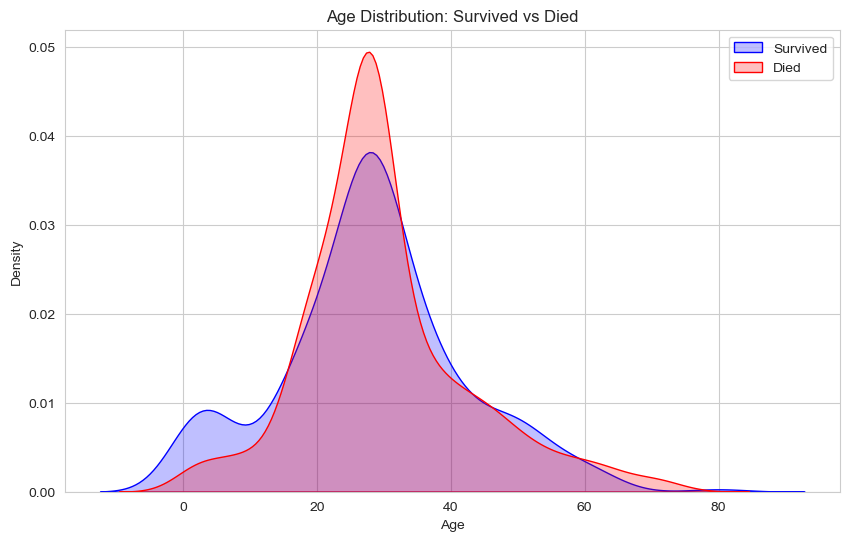

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df['survived'] == 1], x='age', label='Survived', fill=True, color='blue')
sns.kdeplot(data=df[df['survived'] == 0], x='age', label='Died', fill=True, color='red')

plt.title('Age Distribution: Survived vs Died')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [48]:
# This graphic shows being a child differ

**And for defining that kind of differences we should look through the 3 details:**

**- Heatmap**

**- Visualizing with KDE plot or boxplot**

**- Visualizing every feature with target column**

In [51]:
# Final features
final_features = ['survived', 'pclass', 'sex', 'age', 'fare', 'is_alone', 'embarked_S']
df_final = df[final_features]
df_final

,survived,pclass,sex,age,fare,is_alone,embarked_S
0,0,3,1,22.0,7.2500,0,1.0
1,1,1,0,38.0,71.2833,0,0.0
2,1,3,0,26.0,7.9250,1,1.0
3,1,1,0,35.0,53.1000,0,1.0
4,0,3,1,35.0,8.0500,1,1.0
...,...,...,...,...,...,...,...
886,0,2,1,27.0,13.0000,1,1.0
887,1,1,0,19.0,30.0000,1,1.0
888,0,3,0,28.0,23.4500,0,1.0
889,1,1,1,26.0,30.0000,1,0.0


-----------
# **Task 4: Dimensionality Reduction*
Apply PCA to explore the dataset in reduced dimensions.

1. Standardize all numeric features (use StandardScaler — PCA requires standardized data).
2. Fit PCA with all components. Plot the explained variance ratio for each component as a bar chart, and plot the cumulative explained variance as a line chart. How many components do you need to capture at least 80% of the variance?
3. Refit PCA with 2 components. Create a scatter plot of the first two principal components, colored by survived. Can you see any separation between survivors and non-survivors?
4. In a markdown cell, discuss: Does PCA help separate the classes? Would you use PCA as a preprocessing step for this dataset, or is the original feature space sufficient?

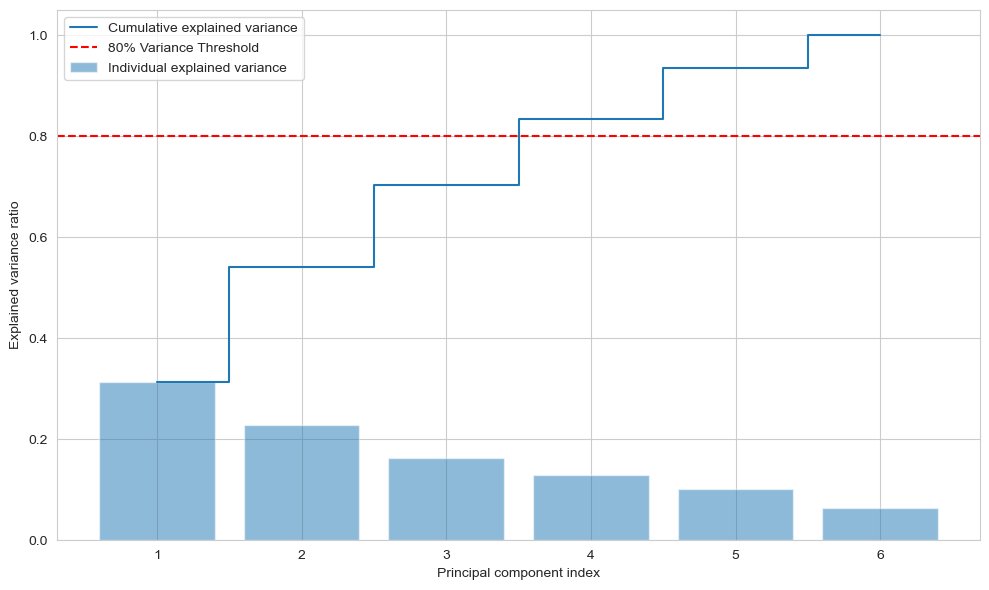

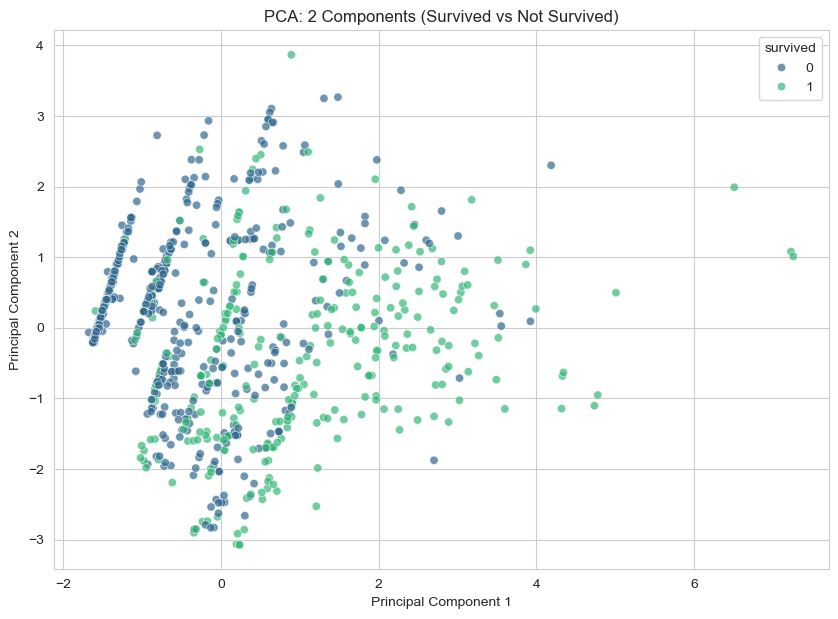

In [54]:
from sklearn.decomposition import PCA
import numpy as np

# 'survived' is our target. So,it should be dropped.
X = df_final.drop('survived', axis=1)
y = df_final['survived']

# StandardScaler (Important for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca_full = PCA()
pca_full.fit(X_scaled)


# Variance ratio
exp_var_pca = pca_full.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_pca)+1), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cum_sum_eigenvalues)+1), cum_sum_eigenvalues, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Variance Threshold')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# All data in PC1 and PC2 
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: 2 Components (Survived vs Not Survived)')
plt.show()


## **Task 4: Dimensionality Reduction using PCA**

### **1. Understanding PCA (Principal Component Analysis)**
PCA is an unsupervised machine learning algorithm used for **dimensionality reduction**. It transforms a large set of variables into a smaller one that still contains most of the information in the original set.

* **Standardization:** Since PCA is distance-based, I applied `StandardScaler` to ensure all features (like Age and Fare) are on the same scale.
* **The Concept:** PCA finds the directions (Principal Components) where the data varies the most. Think of it as finding the best angle to take a 2D "shadow" of 3D objects so that they remain as distinct as possible.



---

### **2. Variance Analysis**

I fitted PCA with all components to analyze how much information (variance) each "Super Column" carries:

* **Individual Variance:** The first component (PC1) captures the most significant patterns in the data (approx. 31%).
* **Cumulative Variance:** By looking at the step-plot, we can see that we need **4 components** to capture at least **80% of the total variance**. 
* **Conclusion:** This means we can reduce our feature space from 6 original features to 4 principal components while retaining 80% of the information.



---

### **3. 2D Visualization (PC1 vs PC2)**

I projected the entire dataset into a 2-dimensional space using the first two principal components.

* **Observation:** The scatter plot shows a significant overlap between survivors (green) and non-survivors (blue). There is no clear linear separation between the classes in this 2D space.
* **Why the overlap?** PCA focuses on maximizing variance, not on separating classes. Since survival depends on complex, non-linear interactions between features (like the "women and children first" rule), reducing the data to just 2 dimensions loses some of these critical details.



---

### **4. Final Discussion**

**Does PCA help separate the classes?**
In this specific case, **no**. The 2D projection does not provide a clear boundary between survivors and non-survivors, suggesting that the most important information for classification might be in the higher-order components or lost during the reduction process.

**Would I use PCA as a preprocessing step for this dataset?**
**No**, I would not recommend PCA for the Titanic dataset for the following reasons:
1.  **Low Dimensionality:** We only have a few features (6-7). PCA is most beneficial for high-dimensional data (e.g., hundreds or thousands of features).
2.  **Loss of Interpretability:** In the original feature space, we can easily understand the impact of "Sex" or "Pclass". In PCA space, these are blended into abstract components that are hard to interpret.
3.  **Feature Sufficiency:** The original features already have strong correlations with the target. Maintaining them allows for better model explainability (SHAP, Feature Importance).


------------
### **Why Standardization is Mandatory for PCA?**
PCA is a **distance-based** algorithm. It works by identifying the directions (Principal Components) that maximize the **variance** (the spread of data points). 

1.  **Sensitivity to Scale:** Variance is calculated based on the numerical ranges of the features. If one feature has a range of 0-500 (like `Fare`) and another has 0-80 (like `Age`), PCA will inherently give more "weight" to the feature with the larger numbers, assuming it is more important.
2.  **Distance Calculation:** Since PCA uses Euclidean distances and covariance matrices behind the scenes, features with larger magnitudes will dominate the results.



3.  **The Solution (StandardScaler):** By applying standardization, we shift the data so that each feature has a **mean of 0** and a **standard deviation of 1**. This ensures that all features contribute equally to the analysis, allowing PCA to find the true underlying patterns rather than just following the largest numbers.
